# Chapter 3: Dimensionality Reduction Techniques

*Reproduction + theoretical summary of Chapter 3 of **scikit-learn Cookbook, Third Edition** (John Sukup, O'Reilly/Packt).*

The book opens this chapter with a cooking analogy: a recipe only works with the right *ingredients*, and in machine learning the ingredients are the **features**. Having more of them is not automatically better. Too many (often redundant or noisy) features make data hard to visualise, slow to process and easy to over-fit. **Dimensionality reduction** distils a dataset into fewer, more useful dimensions while losing as little information as possible.

Three techniques are covered, and each answers a different question:

| Technique | Question it answers | Uses labels? |
|-----------|--------------------|--------------|
| **PCA** | "Which directions carry most of the variance?" | no (unsupervised) |
| **LDA** | "Which directions separate the classes best?" | yes (supervised) |
| **t-SNE** | "How can I *draw* high-dimensional data so that neighbours stay neighbours?" | no (unsupervised) |

The notebook follows the book's recipes in order and adds measurable experiments to each.

| # | Recipe | Main tools |
|---|--------|-----------|
| 1 | Introduction to dimensionality reduction | curse of dimensionality, selection vs. extraction |
| 2 | Transforming datasets with PCA | `PCA`, explained variance, loadings |
| 3 | Maximizing class separability with LDA | `LinearDiscriminantAnalysis` |
| 4 | t-SNE and data visualization | `TSNE`, perplexity, trustworthiness |
| 5 | Selecting the right technique | decision flow (the book's Figure 3.8) |
| 6 | Impact on model performance | trade-offs + the two practical exercises |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

np.random.seed(2024)                       # same seed as the book
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)

print("scikit-learn:", sklearn.__version__)
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)

scikit-learn: 1.9.1
NumPy       : 2.5.3
pandas      : 3.0.6


## 1. Introduction to dimensionality reduction

### 1.1 Why reduce dimensions?

The book gives four reasons:

| Reason | Explanation |
|--------|-------------|
| **Simpler data** | fewer columns are easier to inspect and reason about |
| **Lower computational cost** | fewer features mean faster training and less memory |
| **Better generalisation** | removing redundant/noisy features reduces over-fitting |
| **Visualisation** | we can only draw 2-3 dimensions, so 13 or 64 must be squeezed down |

### 1.2 The curse of dimensionality (a measurable argument)

There is also a mathematical reason to worry about many dimensions. In high-dimensional space, points become almost **equally far apart**, so "near" and "far" lose meaning, which hurts every distance-based method (k-NN, k-means, kernel methods).

The experiment draws 500 random points in $d$ dimensions and compares the largest and smallest pairwise distance through the *relative contrast*

$$\text{contrast}(d)=\frac{d_{\max}-d_{\min}}{d_{\min}}.$$

In [2]:
from scipy.spatial.distance import pdist

rng = np.random.RandomState(0)
rows = []
for d in [2, 10, 100, 1000]:
    points = rng.rand(500, d)                       # 500 random points in the unit cube
    dist = pdist(points)                            # all pairwise Euclidean distances
    rows.append({"dimensions d": d,
                 "smallest distance": dist.min(),
                 "largest distance": dist.max(),
                 "relative contrast": (dist.max() - dist.min()) / dist.min()})

pd.DataFrame(rows).set_index("dimensions d").round(3)

,smallest distance,largest distance,relative contrast
dimensions d,,,
2,0.002,1.324,797.544
10,0.260,2.264,7.694
100,3.001,5.198,0.732
1000,11.911,13.978,0.174


In 2 dimensions the farthest pair is hundreds of times farther apart than the closest pair. In 1000 dimensions the farthest pair is only about **17 %** farther than the closest one: *everything is roughly equally far from everything*. Reducing dimensions restores some of this lost contrast. (Exact values depend on the random draw; the collapse of the contrast with growing $d$ does not.)

### 1.3 Two families: feature selection vs. feature extraction

| | **Feature selection** | **Feature extraction** |
|---|---|---|
| Idea | keep a *subset* of the original columns | build *new* columns as combinations of the originals |
| Original features stay interpretable? | yes | no (a new axis is a blend) |
| Typical methods | filter (statistics/correlation), wrapper (e.g. RFE), embedded (e.g. Lasso) | PCA, LDA, t-SNE |
| Covered in | Chapter 2 (`RFE`, `SelectFromModel`) | **this chapter** |

### 1.4 General workflow suggested by the book

1. Assess the dimensionality of the data and what problems it may cause.
2. Decide whether you need *selection* or *extraction*, and pick a method.
3. Apply it with scikit-learn (inside a `Pipeline`).
4. Train models on the original **and** the reduced data and compare, because reduction is only worth it if the trade-off is acceptable (Section 6).

## 2. Transforming datasets with PCA

### 2.1 Theory

**Principal Component Analysis** rotates the coordinate system so that the first new axis points in the direction of **maximum variance**, the second in the direction of maximum remaining variance *perpendicular* to the first, and so on. Keeping only the first $k$ axes gives a $k$-dimensional summary of the data.

For a standardised data matrix $\mathbf X\in\mathbb R^{n\times p}$ (columns have mean 0):

1. **Covariance matrix:** $\ \mathbf S=\dfrac{1}{n-1}\mathbf X^{\top}\mathbf X$
2. **Eigen-decomposition:** $\ \mathbf S\,\mathbf v_j=\lambda_j\mathbf v_j$, with $\lambda_1\ge\lambda_2\ge\dots\ge\lambda_p$. The eigenvector $\mathbf v_j$ is the $j$-th **principal component direction** and the eigenvalue $\lambda_j$ is the variance along it.
3. **Projection (scores):** $\ \mathbf Z=\mathbf X\,\mathbf V_k$, using the first $k$ eigenvectors as columns of $\mathbf V_k$.
4. **Explained variance ratio:** $\ \text{EVR}_j=\dfrac{\lambda_j}{\sum_{i=1}^{p}\lambda_i}$.

The directions are **orthogonal** (at right angles) and each is a linear combination of the original features. In practice scikit-learn does not form $\mathbf S$ explicitly; it computes a singular value decomposition $\mathbf X=\mathbf U\boldsymbol\Sigma\mathbf V^{\top}$, which gives the same result more stably, with $\lambda_j=\sigma_j^2/(n-1)$.

**Why standardise first?** PCA chases variance, and variance depends on units. A feature measured in the thousands would dominate simply because of its scale (demonstrated in Section 2.7).

### 2.2 The Wine dataset

178 wines from three cultivars, described by 13 chemical measurements. The target (`class`) is separated from the features because PCA must never see it.

In [3]:
from sklearn.datasets import load_wine

wine = load_wine()
df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
target_wine = wine.target

print("shape:", df_wine.shape, "| classes:", {str(n): int(c) for n, c in zip(wine.target_names, np.bincount(target_wine))})
df_wine.head(10)

shape: (178, 13) | classes: {'class_0': 59, 'class_1': 71, 'class_2': 48}


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


### 2.3 PCA inside a pipeline

As the book does, we chain `StandardScaler` and `PCA(n_components=2)` into one `Pipeline`. (For *visualising* the whole dataset we fit on all samples. When PCA feeds a model, it must be fitted on training data only, which Section 6 does.)

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),     # always scale before PCA
    ("pca", PCA(n_components=2)),     # reduce 13 -> 2 dimensions
])

X_pca = pca_pipeline.fit_transform(df_wine)
print("shape before:", df_wine.shape, "-> after:", X_pca.shape)

shape before: (178, 13) -> after: (178, 2)


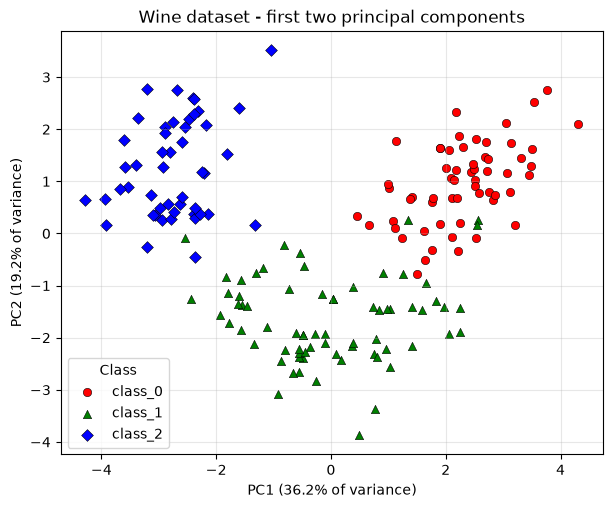

In [5]:
# a small helper reused for every 2-D class plot in this notebook
shapes, colors = ["o", "^", "D"], ["r", "g", "b"]

def plot_wine_2d(ax, X2, y, xlabel, ylabel, title):
    for i, (shape, color) in enumerate(zip(shapes, colors)):
        ax.scatter(X2[y == i, 0], X2[y == i, 1], c=color, marker=shape,
                   edgecolor="black", linewidth=0.4, label=wine.target_names[i])
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(True, alpha=0.3); ax.legend(title="Class")

pca = pca_pipeline.named_steps["pca"]
fig, ax = plt.subplots(figsize=(7, 5.5))
plot_wine_2d(ax, X_pca, target_wine,
             f"PC1 ({pca.explained_variance_ratio_[0]:.1%} of variance)",
             f"PC2 ({pca.explained_variance_ratio_[1]:.1%} of variance)",
             "Wine dataset - first two principal components")
plt.show()

Even though PCA never saw the labels, the three cultivars already form three fairly distinct groups along PC1. That means the largest source of variation in the chemistry is related to the cultivar.

> **📝 Note on the book's arrows.** The book's version of this plot draws two arrows built from `pca.components_[i][0]` and `[i][1]`. Those numbers are the weights of the *first two original features* (alcohol and malic acid) inside each component, so they do not show the direction of PC1 and PC2 (in a plot of PC scores, the axes **are** PC1 and PC2). The meaningful arrow plot is a **biplot**: one arrow per *original feature*, placed at its weights ("loadings") on PC1 and PC2. It shows which chemistry drives each axis:

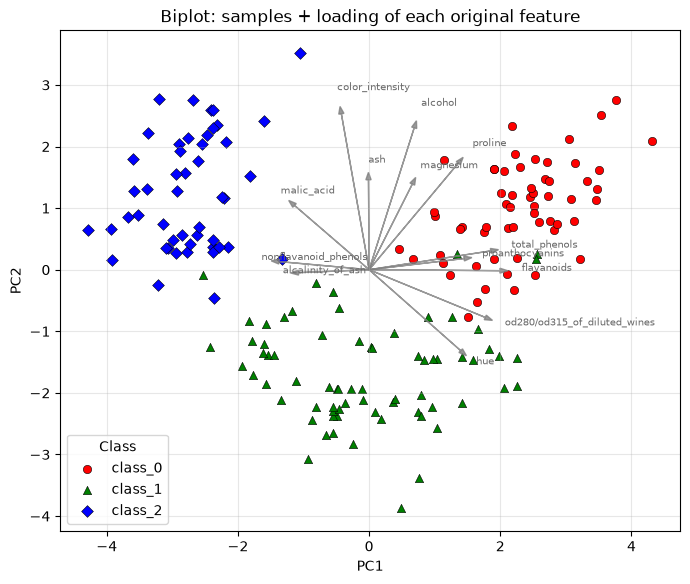

In [6]:
fig, ax = plt.subplots(figsize=(8, 6.5))
plot_wine_2d(ax, X_pca, target_wine, "PC1", "PC2", "Biplot: samples + loading of each original feature")

arrow_scale = 5                                          # purely cosmetic stretch
for name, (l1, l2) in zip(wine.feature_names, pca.components_.T):
    ax.arrow(0, 0, l1 * arrow_scale, l2 * arrow_scale, color="grey", alpha=0.8,
             head_width=0.08, length_includes_head=True)
    ax.text(l1 * arrow_scale * 1.1, l2 * arrow_scale * 1.1, name, fontsize=7, color="dimgrey")
plt.show()

### 2.4 How much information do the components keep?

`explained_variance_ratio_` reports the share of total variance captured by each component. The book sums the two retained components and gets **55.41 %**:

In [7]:
evr = pca.explained_variance_ratio_
print("explained variance ratio of PC1, PC2:", evr.round(4))
print(f"total variance explained by the 2 components: {evr.sum():.2%}")   # book: 55.41%

explained variance ratio of PC1, PC2: [0.362  0.1921]
total variance explained by the 2 components: 55.41%


The first two components carry a bit more than half of the variance, so the 2-D picture above is a useful but **lossy** summary. How many components would we need to keep more? Fit PCA *without* limiting the number of components and look at the **scree plot** (variance per component) together with the **cumulative** curve:

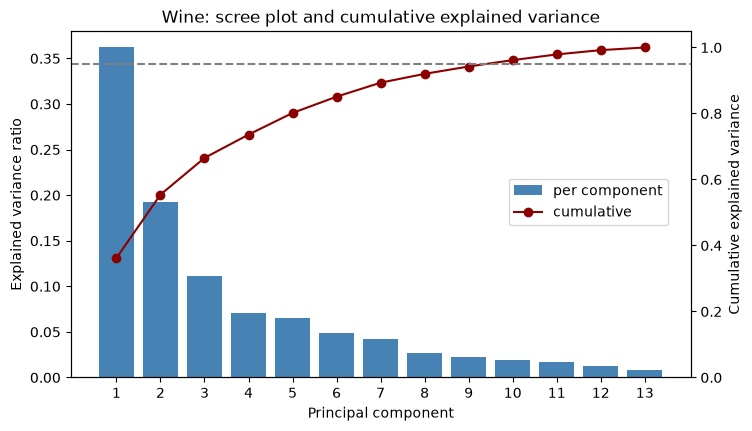

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
explained,0.362,0.192,0.111,0.071,0.066,0.049,0.042,0.027,0.022,0.019,0.017,0.013,0.008
cumulative,0.362,0.554,0.665,0.736,0.802,0.851,0.893,0.920,0.942,0.962,0.979,0.992,1.000


In [8]:
X_wine_scaled = StandardScaler().fit_transform(df_wine)
pca_full = PCA().fit(X_wine_scaled)                       # keep all 13 components
evr_full = pca_full.explained_variance_ratio_
cum = np.cumsum(evr_full)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(np.arange(1, 14), evr_full, color="steelblue", label="per component")
ax.set_xlabel("Principal component"); ax.set_ylabel("Explained variance ratio")
ax.set_xticks(np.arange(1, 14))
ax2 = ax.twinx()
ax2.plot(np.arange(1, 14), cum, "o-", color="darkred", label="cumulative")
ax2.axhline(0.95, ls="--", color="grey"); ax2.set_ylabel("Cumulative explained variance")
ax2.set_ylim(0, 1.05)
ax.set_title("Wine: scree plot and cumulative explained variance")
fig.legend(loc="center right", bbox_to_anchor=(0.88, 0.5))
plt.show()

pd.DataFrame({"explained": evr_full, "cumulative": cum},
             index=[f"PC{i}" for i in range(1, 14)]).round(3).T

Reading the curve: PC1 alone holds about 36 %, and it takes **8 components for 90 %** and **10 components for 95 %** of the variance. Instead of choosing $k$ by hand you can pass a *fraction* to `n_components` and let PCA pick the smallest $k$ that reaches it:

In [9]:
for target in [0.90, 0.95, 0.99]:
    k = PCA(n_components=target).fit(X_wine_scaled).n_components_
    print(f"keep >= {target:.0%} of the variance -> {k} components (of 13)")

keep >= 90% of the variance -> 8 components (of 13)
keep >= 95% of the variance -> 10 components (of 13)
keep >= 99% of the variance -> 12 components (of 13)


### 2.5 Verifying the theory by hand

The book states that PCA is "covariance matrix → eigenvalues/eigenvectors → projection". Let's check that scikit-learn really gives the same numbers as a manual eigen-decomposition:

In [10]:
S = np.cov(X_wine_scaled, rowvar=False)                # 13 x 13 covariance matrix (divides by n-1)
eigvals, eigvecs = np.linalg.eigh(S)                   # eigh: for symmetric matrices
order = np.argsort(eigvals)[::-1]                      # sort largest first
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

print("eigenvalues (manual) :", eigvals[:3].round(4))
print("explained_variance_  :", pca_full.explained_variance_[:3].round(4))
print("eigenvalues match    :", np.allclose(eigvals, pca_full.explained_variance_))

# eigenvectors are only defined up to sign, so compare absolute values
print("directions match     :", np.allclose(np.abs(eigvecs[:, :3].T), np.abs(pca_full.components_[:3])))

# components are orthonormal: V V^T = identity
print("\nfirst 3 components times their transpose (should be the identity):")
print((pca_full.components_[:3] @ pca_full.components_[:3].T).round(6))

eigenvalues (manual) : [4.7324 2.5111 1.4542]
explained_variance_  : [4.7324 2.5111 1.4542]
eigenvalues match    : True
directions match     : True

first 3 components times their transpose (should be the identity):
[[ 1. -0.  0.]
 [-0.  1. -0.]
 [ 0. -0.  1.]]


The eigenvalues and directions coincide, and the components are mutually orthogonal, exactly as the theory says. (The sign of a component is arbitrary, which is why we compare absolute values. A flipped sign between two runs or library versions is harmless.)

### 2.6 Interpreting the components (loadings)

Each row of `components_` lists how much every original feature contributes to a component. Large positive and negative entries are the features that define the axis.

In [11]:
loadings = pd.DataFrame(pca_full.components_[:2].T, index=wine.feature_names, columns=["PC1", "PC2"])
loadings.sort_values("PC1").round(2)

,PC1,PC2
nonflavanoid_phenols,-0.30,0.03
malic_acid,-0.25,0.22
alcalinity_of_ash,-0.24,-0.01
color_intensity,-0.09,0.53
ash,-0.00,0.32
magnesium,0.14,0.30
alcohol,0.14,0.48
proline,0.29,0.36
hue,0.30,-0.28
proanthocyanins,0.31,0.04


* **PC1** contrasts the *phenolic* measurements (flavanoids, total phenols, OD280/OD315, proanthocyanins, hue: strongly positive) with non-flavanoid phenols, malic acid and alkalinity of ash (negative). In this run it separates class 0 (right) from class 2 (left) in the scatter plot (the sign of a component can flip between runs or versions, which only mirrors the picture).
* **PC2** is driven mainly by colour intensity, alcohol, proline and ash, which is the axis that separates class 1 from the other two.

This is the price of feature *extraction*: each new axis is a blend, so interpretation requires reading loadings like these.

### 2.7 Why scaling matters for PCA

Wine's features live on very different scales (proline is in the hundreds/thousands, hue is around 1). Without scaling, PCA simply finds the feature with the biggest numbers:

In [12]:
pca_raw = PCA(n_components=2).fit(df_wine)             # NO scaling
top = np.argmax(np.abs(pca_raw.components_[0]))

print("explained variance ratio, UNSCALED:", pca_raw.explained_variance_ratio_.round(4))
print("feature dominating PC1 (loading):  ", wine.feature_names[top], round(pca_raw.components_[0][top], 3))
print("\nfeature standard deviations (original units):")
print(df_wine.std().round(2).sort_values(ascending=False).head(4).to_string())

explained variance ratio, UNSCALED: [0.9981 0.0017]
feature dominating PC1 (loading):   proline 1.0

feature standard deviations (original units):
proline              314.91
magnesium             14.28
alcalinity_of_ash      3.34
color_intensity        2.32


Without scaling, PC1 "explains" about **99.8 %** of the variance, but that is an artefact: PC1 is essentially the `proline` column (loading ≈ 1.0) because its standard deviation (≈ 315) dwarfs every other feature (the next largest is ≈ 14). Other chemistry is invisible. After standardisation every feature has variance 1, so none can dominate by units alone, which is why the book repeats *"always scale before PCA"*.

### 2.8 Information loss: reconstruction error

PCA can run backwards (`inverse_transform`) to rebuild an approximation of the original data from $k$ components. The error of the reconstruction shows precisely how much has been thrown away:

In [13]:
rows = []
for k in [1, 2, 5, 8, 13]:
    p_k = PCA(n_components=k).fit(X_wine_scaled)
    X_back = p_k.inverse_transform(p_k.transform(X_wine_scaled))
    rows.append({"components kept": k,
                 "variance kept": p_k.explained_variance_ratio_.sum(),
                 "mean squared reconstruction error": np.mean((X_wine_scaled - X_back) ** 2)})
pd.DataFrame(rows).set_index("components kept").round(3)

,variance kept,mean squared reconstruction error
components kept,,
1,0.362,0.638
2,0.554,0.446
5,0.802,0.198
8,0.920,0.080
13,1.000,0.000


The error is simply "what was not kept": with 2 components the error per entry is 0.446, which is $1-0.554$ (variance kept = 55.4 %), and with all 13 components it is exactly 0 (a pure rotation loses nothing). The relation *error = 1 − variance kept* holds here because every standardised feature has variance 1.

### 2.9 PCA on just two features (the book's Figure 3.4)

With only two features, PCA is easy to see: it **rotates** the axes so that the first points along the direction of greatest spread. The top row shows two pairs of standardised features with the two PCA directions drawn on them; the bottom row shows the same points expressed in the new coordinates.

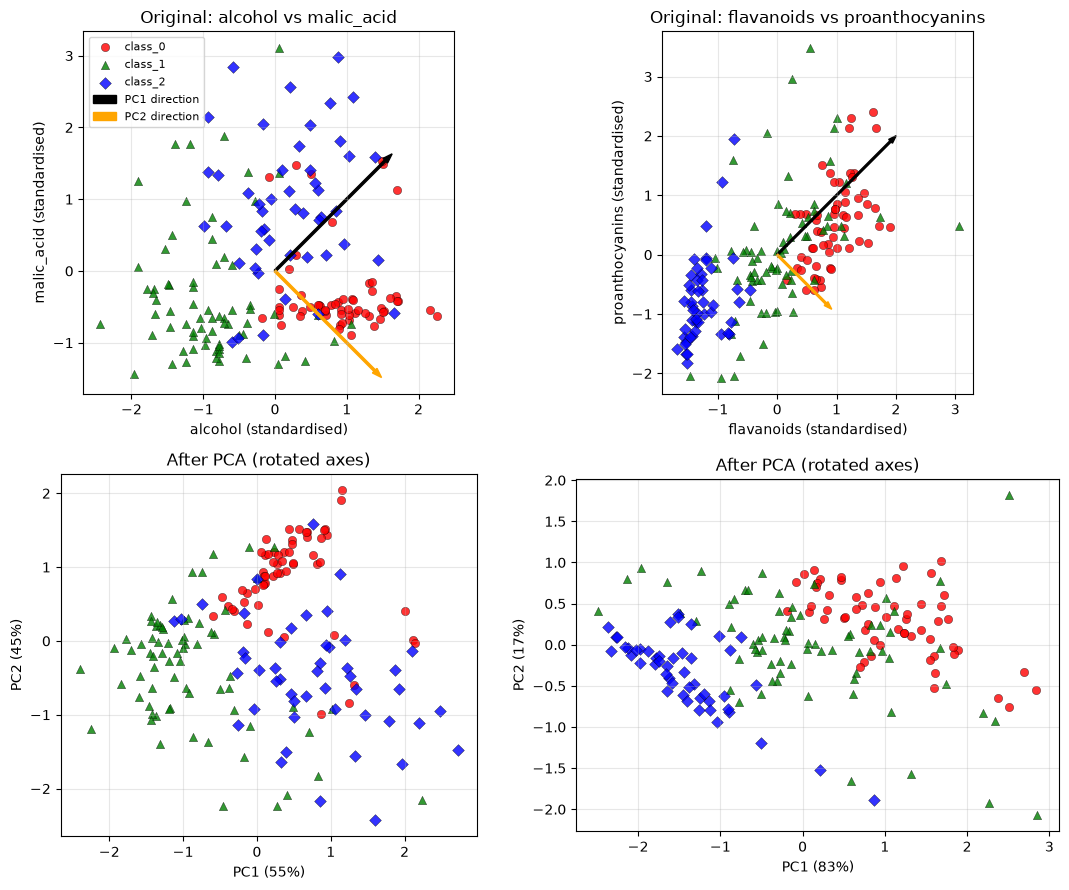

In [14]:
pairs = [("alcohol", "malic_acid"), ("flavanoids", "proanthocyanins")]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for col, (fa, fb) in enumerate(pairs):
    Z2 = StandardScaler().fit_transform(df_wine[[fa, fb]])
    p2 = PCA(n_components=2).fit(Z2)
    T2 = p2.transform(Z2)

    # top: original standardised features + the two PCA directions
    ax = axes[0, col]
    for i, (shape, color) in enumerate(zip(shapes, colors)):
        ax.scatter(Z2[target_wine == i, 0], Z2[target_wine == i, 1], c=color, marker=shape,
                   edgecolor="black", linewidth=0.3, label=wine.target_names[i], alpha=0.8)
    for j, (vec, var) in enumerate(zip(p2.components_, p2.explained_variance_)):
        ax.arrow(0, 0, *(vec * 2.2 * np.sqrt(var)), color=["black", "orange"][j], width=0.03,
                 length_includes_head=True, label=f"PC{j+1} direction")
    ax.set_xlabel(fa + " (standardised)"); ax.set_ylabel(fb + " (standardised)")
    ax.set_title(f"Original: {fa} vs {fb}"); ax.set_aspect("equal"); ax.grid(alpha=0.3)
    if col == 0: ax.legend(fontsize=8)

    # bottom: same points in PC coordinates
    ax = axes[1, col]
    for i, (shape, color) in enumerate(zip(shapes, colors)):
        ax.scatter(T2[target_wine == i, 0], T2[target_wine == i, 1], c=color, marker=shape,
                   edgecolor="black", linewidth=0.3, alpha=0.8)
    ax.set_xlabel(f"PC1 ({p2.explained_variance_ratio_[0]:.0%})"); ax.set_ylabel(f"PC2 ({p2.explained_variance_ratio_[1]:.0%})")
    ax.set_title("After PCA (rotated axes)"); ax.set_aspect("equal"); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

Top row: the black arrow (PC1) follows the long axis of the point cloud and the orange arrow (PC2) is perpendicular to it. Bottom row: the very same points, but now PC1 is the horizontal axis. With two features and two components nothing is lost; it is only a rotation (the variance ratios sum to 100 %). Real dimensionality reduction happens when we *drop* the later components, as we did for all 13 features above.

> **Takeaways for PCA:** unsupervised · needs scaled data · components are orthogonal linear blends of the features · fast · can transform **new** data (`transform`) · hard to interpret beyond the loadings.

## 3. Maximizing class separability with LDA

### 3.1 Theory

PCA ignores labels, so the direction of greatest variance need not be the direction that tells the classes apart. **Linear Discriminant Analysis** uses the labels to look for directions along which **class means are far apart relative to the spread inside each class**.

Let $\boldsymbol\mu_k$ be the mean of class $k$ (with $n_k$ samples) and $\boldsymbol\mu$ the overall mean. Define

$$\mathbf S_W=\sum_{k}\sum_{\mathbf x\in C_k}(\mathbf x-\boldsymbol\mu_k)(\mathbf x-\boldsymbol\mu_k)^{\top}\quad\text{(within-class scatter)},\qquad
\mathbf S_B=\sum_k n_k(\boldsymbol\mu_k-\boldsymbol\mu)(\boldsymbol\mu_k-\boldsymbol\mu)^{\top}\quad\text{(between-class scatter)}.$$

LDA looks for directions $\mathbf w$ that maximise Fisher's criterion

$$J(\mathbf w)=\frac{\mathbf w^{\top}\mathbf S_B\,\mathbf w}{\mathbf w^{\top}\mathbf S_W\,\mathbf w},$$

whose solutions are the leading eigenvectors of $\mathbf S_W^{-1}\mathbf S_B$.

**Important limit:** $\mathbf S_B$ is built from $K$ class means, so it has rank at most $K-1$. Hence LDA can produce at most

$$\min(p,\;K-1)\ \text{components}$$

($p$ features, $K$ classes). For Wine ($K=3$) that is 2, which is why the book uses `n_components=2`.

**Assumptions** (which is why the book also standardises): each class is roughly Gaussian and all classes share the same covariance matrix.

### 3.2 LDA on the Wine dataset

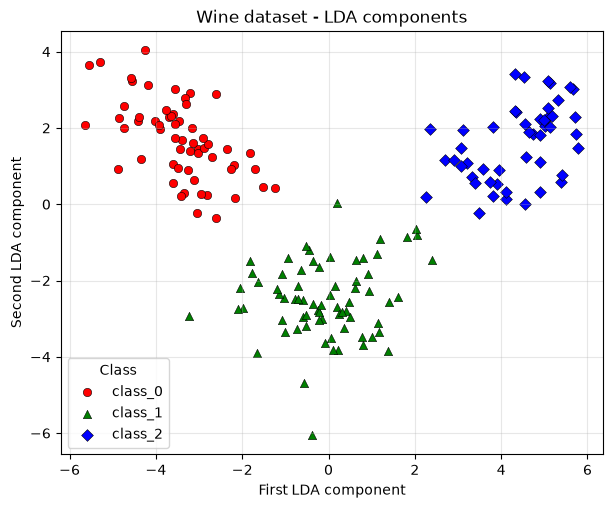

share of between-class variance per component: [0.687 0.313]


In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X_wine, y_wine = wine.data, wine.target

lda_pipeline_wine = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(n_components=2)),   # min(n_features, n_classes - 1) = 2
])

X_lda_wine = lda_pipeline_wine.fit_transform(X_wine, y_wine)        # note: LDA needs y here!

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_wine_2d(ax, X_lda_wine, y_wine, "First LDA component", "Second LDA component",
             "Wine dataset - LDA components")
plt.show()

print("share of between-class variance per component:",
      lda_pipeline_wine.named_steps["lda"].explained_variance_ratio_.round(3))

The classes are now almost cleanly separated, and the first discriminant alone does most of the work (about 69 % of the between-class variance). The call differs from PCA in one visible way: `fit_transform(X, y)` **requires the labels**.

What happens if we ask for more components than allowed?

In [16]:
try:
    LinearDiscriminantAnalysis(n_components=3).fit(X_wine_scaled, y_wine)
except ValueError as e:
    print("ValueError:", e)

ValueError: n_components cannot be larger than min(n_features, n_classes - 1).


### 3.3 PCA vs. LDA side by side

Both plots use the same data. PCA looks for variance, LDA for class separation.

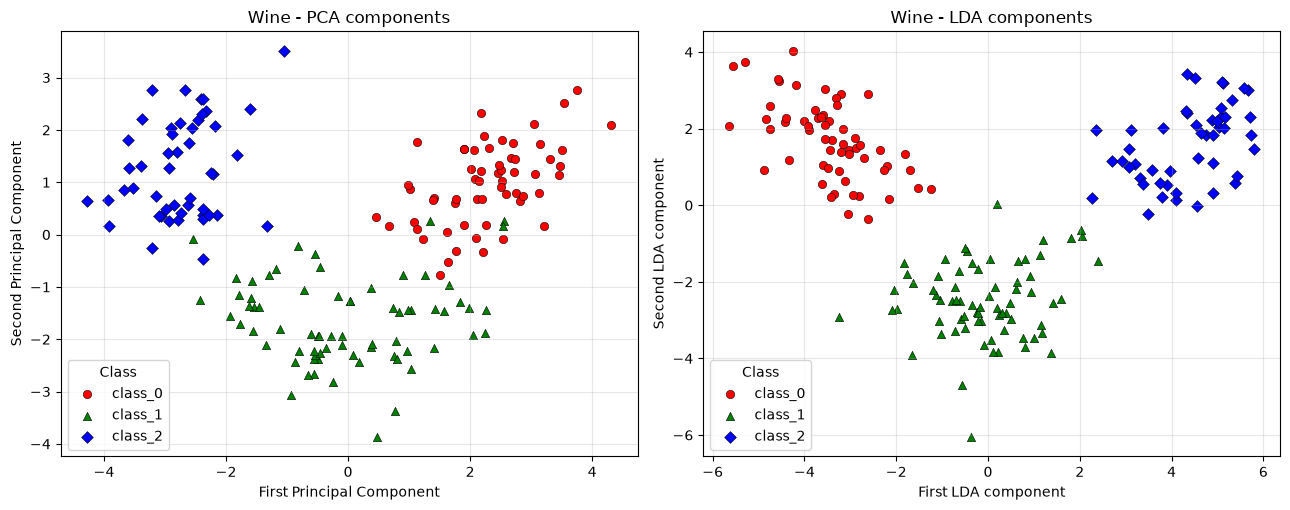

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_wine_2d(axes[0], X_pca, y_wine, "First Principal Component", "Second Principal Component", "Wine - PCA components")
plot_wine_2d(axes[1], X_lda_wine, y_wine, "First LDA component", "Second LDA component", "Wine - LDA components")
plt.tight_layout(); plt.show()

The book comments that class separation is "a little more striking" with LDA, partly because LDA is supervised. Let's put numbers on this *and* check the caveat. Both reducers feed the same logistic regression and are scored by **repeated stratified 5-fold cross-validation**. The reducer sits inside the pipeline, so it is re-fitted on each training fold (no leakage).

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)

variants = {
    "all 13 features (no reduction)": None,
    "PCA -> 2 components":            PCA(n_components=2),
    "PCA -> 5 components":            PCA(n_components=5),
    "LDA -> 1 component":             LinearDiscriminantAnalysis(n_components=1),
    "LDA -> 2 components":            LinearDiscriminantAnalysis(n_components=2),
}

rows = {}
for name, reducer in variants.items():
    steps = [StandardScaler()] + ([reducer] if reducer is not None else []) + [LogisticRegression(max_iter=2000)]
    scores = cross_val_score(Pipeline([(f"s{i}", s) for i, s in enumerate(steps)]), X_wine, y_wine, cv=cv)
    rows[name] = {"mean accuracy": scores.mean(), "std": scores.std()}

pd.DataFrame(rows).T.round(3)

,mean accuracy,std
all 13 features (no reduction),0.980,0.022
PCA -> 2 components,0.964,0.027
PCA -> 5 components,0.977,0.025
LDA -> 1 component,0.915,0.041
LDA -> 2 components,0.988,0.014


Reading the table (50 folds per row):

* **LDA with 2 components** matches or slightly beats the full 13-feature model (0.988 vs 0.980; the gap is smaller than the fold-to-fold spread of ≈ 0.02, so call it "equal").
* **PCA with 2 components** is clearly worse (≈ 0.964): PCA chose the directions of greatest variance, not the most informative ones for the classes. PCA needs about 5 components to catch up.
* **LDA with 1 component** drops to ≈ 0.915: with three classes one direction cannot separate everything.

So for a classification task, a supervised reduction gives the same accuracy from far fewer dimensions.

### 3.4 The supervised caveat: a pretty plot is not proof

Because LDA uses the labels, an *in-sample* LDA scatter plot can look perfectly separated even when there is **no signal at all**. To show it, take pure random noise (60 samples, 50 random features, 3 arbitrary classes):

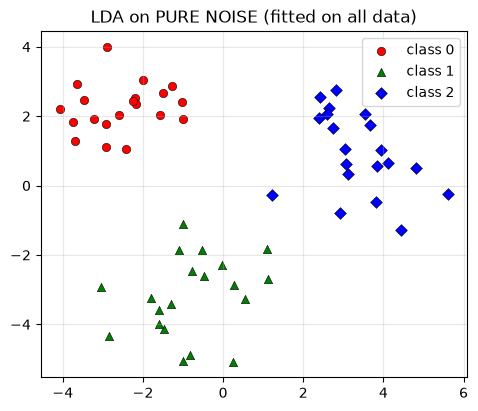

LDA fitted BEFORE cross-validation (leaky): accuracy = 1.000
LDA inside the pipeline (correct)         : accuracy = 0.317   (chance = 0.333)


In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold

rng = np.random.RandomState(1)
X_noise = rng.normal(size=(60, 50))
y_noise = np.repeat([0, 1, 2], 20)                       # labels unrelated to X

X_noise_lda = LinearDiscriminantAnalysis(n_components=2).fit_transform(X_noise, y_noise)   # fitted on ALL data

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for i, (shape, color) in enumerate(zip(shapes, colors)):
    ax.scatter(X_noise_lda[y_noise == i, 0], X_noise_lda[y_noise == i, 1], c=color, marker=shape,
               edgecolor="black", linewidth=0.4, label=f"class {i}")
ax.set_title("LDA on PURE NOISE (fitted on all data)"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

skf = StratifiedKFold(5, shuffle=True, random_state=0)
leaky = cross_val_score(KNeighborsClassifier(), X_noise_lda, y_noise, cv=skf).mean()
clean = cross_val_score(Pipeline([("lda", LinearDiscriminantAnalysis(n_components=2)),
                                  ("knn", KNeighborsClassifier())]), X_noise, y_noise, cv=skf).mean()
print(f"LDA fitted BEFORE cross-validation (leaky): accuracy = {leaky:.3f}")
print(f"LDA inside the pipeline (correct)         : accuracy = {clean:.3f}   (chance = 0.333)")

With 50 features and only 60 samples, LDA can always find directions that split three arbitrary groups, so the plot shows three clearly separated clusters and the leaky evaluation reports 100 % accuracy on **noise**. The honest pipeline version scores about chance level. The lesson mirrors Chapter 2: *a supervised transformer (LDA, feature selection) must be fitted on training data only*, i.e. inside the pipeline.

> **Takeaways for LDA:** supervised · at most $K-1$ components · assumes Gaussian classes with a shared covariance · fast · can `transform` new data · also usable directly as a classifier (`predict`).

## 4. t-SNE and data visualization

### 4.1 Theory

PCA and LDA are *linear*: they can only rotate and project. **t-distributed Stochastic Neighbor Embedding** is **non-linear** and has a single purpose: producing a 2-D or 3-D *map* in which points that were neighbours in the original space stay neighbours.

1. **Similarities in the original space.** For each point $i$, a Gaussian turns distances into probabilities that $j$ is its neighbour:
$$p_{j\mid i}=\frac{\exp\!\bigl(-\lVert\mathbf x_i-\mathbf x_j\rVert^2/2\sigma_i^2\bigr)}{\sum_{k\neq i}\exp\!\bigl(-\lVert\mathbf x_i-\mathbf x_k\rVert^2/2\sigma_i^2\bigr)},\qquad p_{ij}=\frac{p_{j\mid i}+p_{i\mid j}}{2n}.$$
   The width $\sigma_i$ is tuned per point so that every point has the same **perplexity**, which can be read as "the effective number of neighbours" (default 30).
2. **Similarities in the map.** Points $\mathbf y_i$ in 2-D use a heavy-tailed Student-t distribution (1 degree of freedom):
$$q_{ij}=\frac{(1+\lVert\mathbf y_i-\mathbf y_j\rVert^2)^{-1}}{\sum_{k\neq l}(1+\lVert\mathbf y_k-\mathbf y_l\rVert^2)^{-1}}.$$
   The heavy tails let moderately distant points sit far apart in the map, which avoids the "crowding problem" of squeezing everything together.
3. **Optimisation.** Move the map points by gradient descent to minimise the mismatch between $P$ and $Q$, the Kullback-Leibler divergence
$$\mathrm{KL}(P\Vert Q)=\sum_{i\neq j}p_{ij}\log\frac{p_{ij}}{q_{ij}}.$$

**Things t-SNE does *not* give you** (important for reading its plots): cluster *sizes* and the *distances between* clusters are not reliable; the axes have no meaning; results depend on perplexity and the random seed; and scikit-learn's `TSNE` has **no `transform()`**, so it cannot place new data into an existing map. It is a visualisation tool, not a preprocessing step.

### 4.2 The Digits dataset

> **📝 Note.** The book calls this dataset "MNIST", but `load_digits()` is the small UCI *Optical Recognition of Handwritten Digits* set: **1 797** images of **8×8 pixels** (64 features, integer values 0-16), not the 70 000-image 28×28 MNIST. The book's description of its construction (32×32 bitmaps pooled into 8×8 blocks) refers to this UCI set.

data shape: (1797, 64) | classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
samples per class: [178, 182, 177, 183, 181, 182, 181, 179, 174, 180]


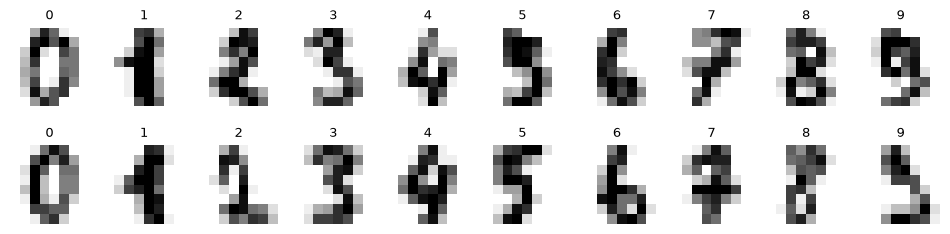

In [20]:
from sklearn.datasets import load_digits

digits = load_digits()
print("data shape:", digits.data.shape, "| classes:", np.unique(digits.target).tolist())
print("samples per class:", np.bincount(digits.target).tolist())

fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
for ax, img, lab in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap="gray_r"); ax.set_title(lab, fontsize=9); ax.axis("off")
plt.show()

### 4.3 t-SNE in a pipeline

Following the book: standardise, then `TSNE(n_components=2)`. This is the slowest cell of the notebook (about 10-15 seconds).

t-SNE finished in 5.0 s; embedding shape: (1797, 2)


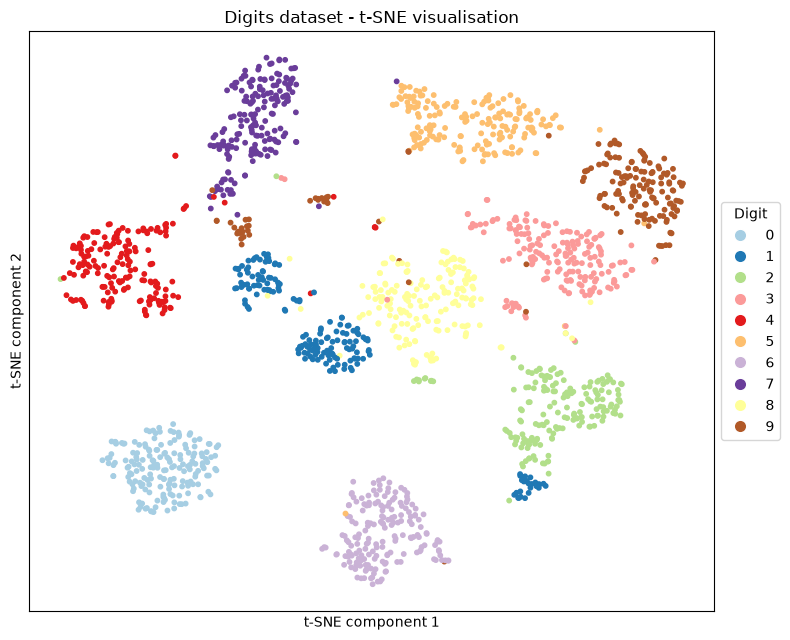

In [21]:
from sklearn.manifold import TSNE

tsne_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("tsne", TSNE(n_components=2, random_state=2024)),
])

t0 = time.perf_counter()
X_tsne = tsne_pipeline.fit_transform(digits.data)
t_tsne = time.perf_counter() - t0
print(f"t-SNE finished in {t_tsne:.1f} s; embedding shape: {X_tsne.shape}")

def plot_digits_2d(ax, X2, labels, title, legend=True):
    ax.scatter(X2[:, 0], X2[:, 1], c=labels, cmap="Paired", s=10)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    if legend:
        handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=plt.cm.Paired(i / 9),
                              label=str(i), markersize=9) for i in range(10)]
        ax.legend(handles=handles, title="Digit", loc="center left", bbox_to_anchor=(1, 0.5))

fig, ax = plt.subplots(figsize=(8, 6.5))
plot_digits_2d(ax, X_tsne, digits.target, "Digits dataset - t-SNE visualisation")
ax.set_xlabel("t-SNE component 1"); ax.set_ylabel("t-SNE component 2")
plt.tight_layout(); plt.show()

Ten classes in 64 dimensions become ten recognisable islands. The labels were used **only for colouring**, never by t-SNE. As the book notes, the neighbourhoods make sense: look at which digits sit next to each other (visually similar shapes tend to be close) and which ones stand apart.

### 4.4 Quantifying "how well are neighbours preserved?" (trustworthiness)

"It looks good" is subjective. **Trustworthiness** (`sklearn.manifold.trustworthiness`) scores from 0 to 1 how well the *nearest neighbours in the map* are also nearest neighbours in the original space (1 = perfect). We compare three 2-D embeddings of the same 64-D data: PCA, LDA and t-SNE.

In [22]:
from sklearn.manifold import trustworthiness

Z_digits = StandardScaler().fit_transform(digits.data)          # the 64-D space the embeddings come from

t0 = time.perf_counter(); X_pca_d = PCA(n_components=2).fit_transform(Z_digits);                     t_pca = time.perf_counter() - t0
t0 = time.perf_counter(); X_lda_d = LinearDiscriminantAnalysis(n_components=2).fit_transform(Z_digits, digits.target); t_lda = time.perf_counter() - t0

embeddings = {"PCA (2 comps)": X_pca_d, "LDA (2 comps)": X_lda_d, "t-SNE (2 comps)": X_tsne}
pd.Series({n: trustworthiness(Z_digits, E, n_neighbors=10) for n, E in embeddings.items()},
          name="trustworthiness (k=10)").round(3).to_frame()

,trustworthiness (k=10)
PCA (2 comps),0.816
LDA (2 comps),0.765
t-SNE (2 comps),0.986


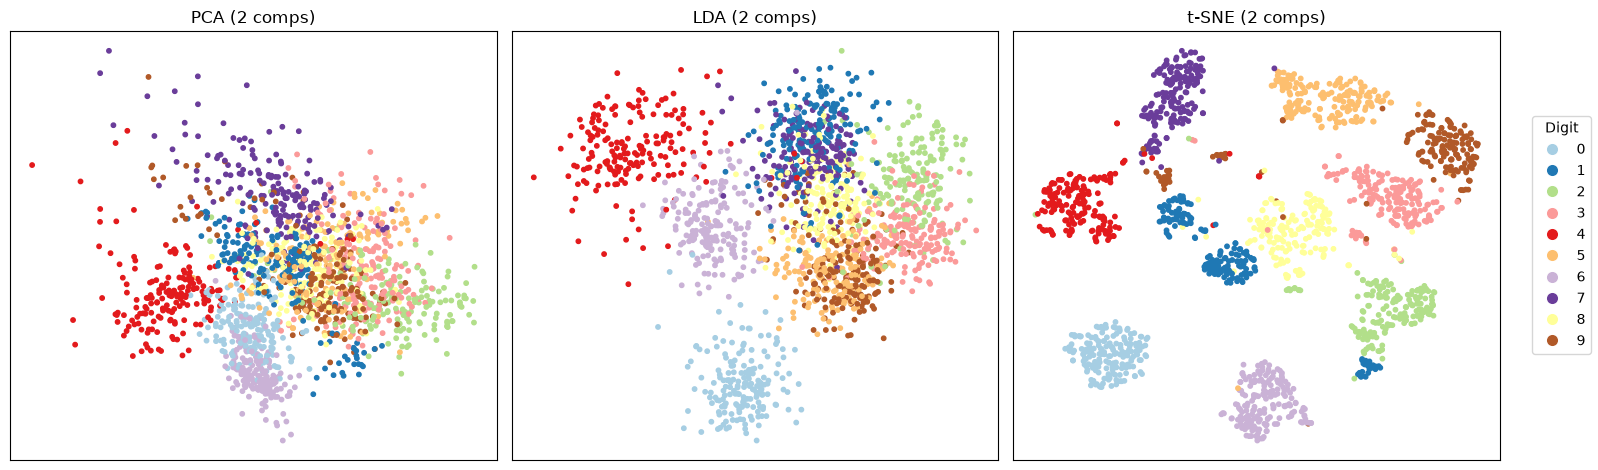

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (name, E) in zip(axes, embeddings.items()):
    plot_digits_2d(ax, E, digits.target, name, legend=False)
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=plt.cm.Paired(i / 9), label=str(i), markersize=9) for i in range(10)]
fig.legend(handles=handles, title="Digit", loc="center right")
plt.tight_layout(rect=(0, 0, 0.95, 1)); plt.show()

t-SNE preserves local neighbourhoods far better (≈ 0.99) than either linear method (PCA ≈ 0.82, LDA ≈ 0.77). That is exactly what it is built for. Note that LDA scores *lowest* here, which is not a flaw: it optimises class separation, not neighbourhood preservation. With 10 classes it can only produce 9 discriminant directions, and 2 of them cannot hold all ten classes apart.

### 4.5 The perplexity parameter

Perplexity sets the neighbourhood size t-SNE pays attention to. Too small and the map fragments into many tiny groups (it only sees very local structure); larger values consider broader structure.

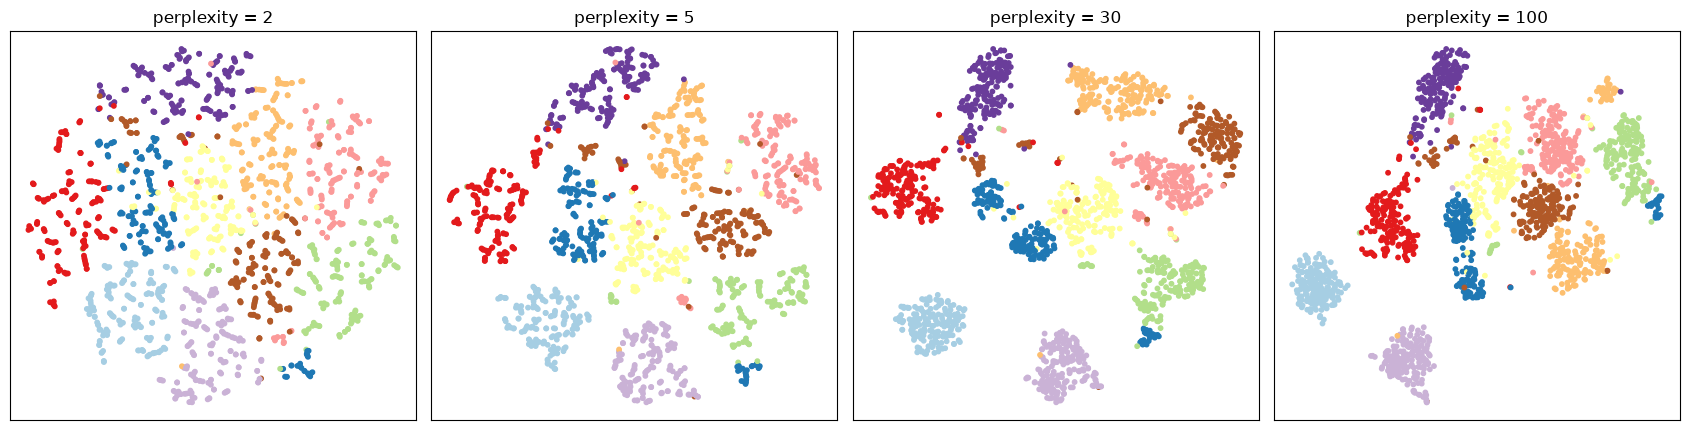

,trustworthiness (k=10)
perplexity,
2,0.970
5,0.982
30,0.986
100,0.984


In [24]:
perplexities = [2, 5, 30, 100]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
trust = {}
for ax, per in zip(axes, perplexities):
    emb = TSNE(n_components=2, perplexity=per, random_state=0).fit_transform(Z_digits)
    trust[per] = trustworthiness(Z_digits, emb, n_neighbors=10)
    plot_digits_2d(ax, emb, digits.target, f"perplexity = {per}", legend=False)
plt.tight_layout(); plt.show()

pd.Series(trust, name="trustworthiness (k=10)").rename_axis("perplexity").round(3).to_frame()

With perplexity 2 the classes break into many small fragments and trustworthiness is lowest (≈ 0.97); from 5 to 100 the maps and scores are similar (≈ 0.98). On clean data like this the default (30) is a safe choice, but the book's advice to explore the setting is wise: on messier data different perplexities can tell different stories, so look at several.

### 4.6 Randomness and the missing `transform()`

Two practical warnings. First, the layout depends on the random seed, so two runs can place the same clusters in different corners (the *neighbourhoods* should agree, the *positions* need not):

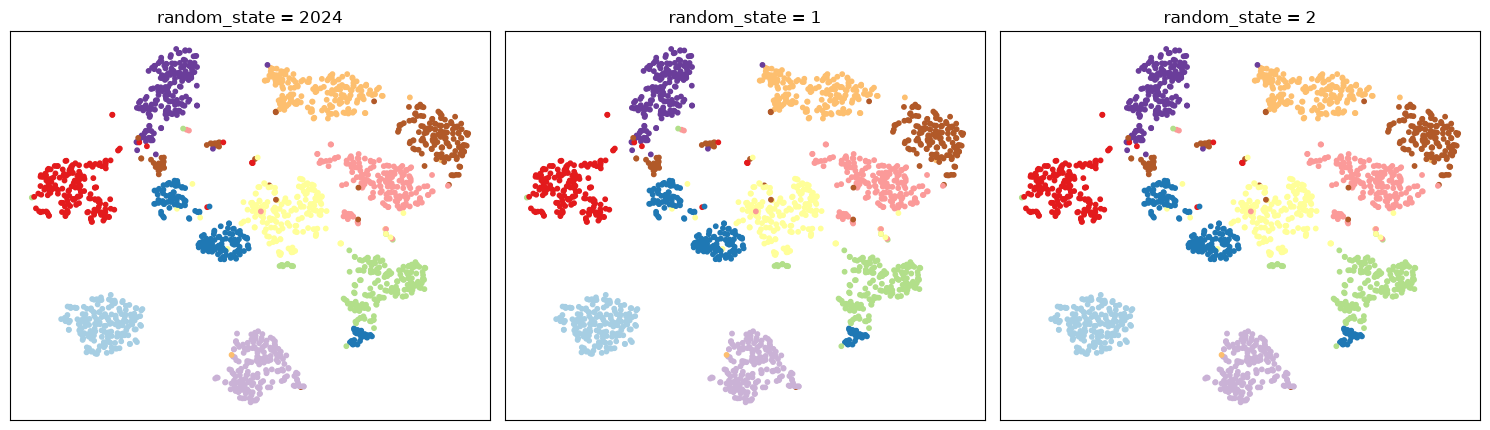

{'random_state=2024': 0.986, 'random_state=1': 0.986, 'random_state=2': 0.986}


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
seed_trust = {}
for ax, seed in zip(axes, [2024, 1, 2]):
    emb = X_tsne if seed == 2024 else TSNE(n_components=2, random_state=seed).fit_transform(Z_digits)
    seed_trust[f"random_state={seed}"] = trustworthiness(Z_digits, emb, n_neighbors=10)
    plot_digits_2d(ax, emb, digits.target, f"random_state = {seed}", legend=False)
plt.tight_layout(); plt.show()
print({k: round(float(v), 3) for k, v in seed_trust.items()})

The three maps look different, but their quality scores are almost identical. Second, unlike PCA and LDA, t-SNE cannot embed new samples:

In [26]:
for name, est in [("PCA", PCA()), ("LDA", LinearDiscriminantAnalysis()), ("TSNE", TSNE())]:
    print(f"{name:<5} has transform()? {hasattr(est, 'transform')}")

PCA   has transform()? True
LDA   has transform()? True
TSNE  has transform()? False


`TSNE` only offers `fit_transform`: if new data arrives you must recompute the whole map (and the layout will change). Therefore t-SNE belongs to the **exploration/visualisation** stage and should not be placed in a model's preprocessing pipeline.

> **Takeaways for t-SNE:** non-linear · for visualisation only · excellent at local structure · slow · stochastic (set `random_state`) · tune perplexity · don't read meaning into cluster sizes or the gaps between clusters.

## 5. Selecting the right technique

### 5.1 The decision flow (the book's Figure 3.8)

The book's flowchart can be written as a sequence of questions:

| Step | Question | If YES | If NO |
|------|----------|--------|-------|
| 1 | Do you have **labelled data** *and* want **class separation**? | **LDA** | go to step 2 |
| 2 | Is the primary goal **visualisation** (2-D/3-D)? | go to step 3 | go to step 4 |
| 3 | Do you need to preserve **local structure / clusters** (non-linear)? | **t-SNE** | **PCA** (global structure) |
| 4 | (Pre-processing) Do you need **interpretability**, **speed**, or to **transform new data**? | **PCA** (yes to *any* of them) | *(chart ends)* |

### 5.2 Comparison table (the book's Table 3.1) and guidelines

| Technique | Type | Purpose | Key features | Best use cases |
|-----------|------|---------|--------------|----------------|
| **PCA** | unsupervised | dimensionality reduction | maximises variance; linear combinations of features | exploratory analysis, noise reduction, feature extraction |
| **LDA** | supervised | dimensionality reduction | maximises class separability; linear discriminants | classification where class separation matters |
| **t-SNE** | unsupervised | visualisation | non-linear; reveals clusters; preserves local structure | visualising high-dimensional data, exploration |

The book also lists factors to weigh: *supervised vs. unsupervised*, *variance vs. class separability*, *feature extraction vs. visualisation*, *efficiency* (PCA fast; LDA needs class means/covariances; t-SNE iterative and expensive) and *interpretability* (PCA loadings are blends; LDA discriminants relate to class separation; t-SNE axes carry no meaning).

### 5.3 The same comparison, measured on the Digits data

Instead of only asserting these properties, we can check several of them on the objects from Section 4:

In [27]:
overview = pd.DataFrame({
    "uses labels?":          {"PCA": "no",  "LDA": "yes", "t-SNE": "no"},
    "max components":        {"PCA": "min(n, p) = 64", "LDA": "K-1 = 9", "t-SNE": "2-3 (visualisation)"},
    "can transform new data?": {"PCA": hasattr(PCA(), "transform"),
                                "LDA": hasattr(LinearDiscriminantAnalysis(), "transform"),
                                "t-SNE": hasattr(TSNE(), "transform")},
    "time on Digits (s)":    {"PCA": t_pca, "LDA": t_lda, "t-SNE": t_tsne},
    "trustworthiness (2-D)": {"PCA": trustworthiness(Z_digits, X_pca_d, n_neighbors=10),
                              "LDA": trustworthiness(Z_digits, X_lda_d, n_neighbors=10),
                              "t-SNE": trustworthiness(Z_digits, X_tsne, n_neighbors=10)},
})
overview

,uses labels?,max components,can transform new data?,time on Digits (s),trustworthiness (2-D)
PCA,no,"min(n, p) = 64",True,0.005,0.816
LDA,yes,K-1 = 9,True,0.035,0.765
t-SNE,no,2-3 (visualisation),False,4.994,0.986


The measured column matches the book's qualitative claims: on this *small* dataset PCA and LDA finish in milliseconds while t-SNE needs seconds (the gap widens quickly with more samples), only t-SNE cannot transform new data, and t-SNE wins on neighbourhood preservation.

### 5.4 Combining techniques

The book suggests, when unsure, trying more than one method, for instance **PCA followed by t-SNE**: PCA first removes noise and shrinks the input, then t-SNE draws the map. This is a common recipe for large, very wide data. On our small Digits set it gives the same map quality (no speed-up is expected at this size):

In [28]:
t0 = time.perf_counter()
X_pca30 = PCA(n_components=30).fit_transform(Z_digits)
X_pca_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_pca30)
t_combo = time.perf_counter() - t0

print(f"PCA(30) -> t-SNE : {t_combo:.1f} s, trustworthiness = {trustworthiness(Z_digits, X_pca_tsne, n_neighbors=10):.3f}")
print(f"t-SNE alone      : {t_tsne:.1f} s, trustworthiness = {trustworthiness(Z_digits, X_tsne, n_neighbors=10):.3f}")

PCA(30) -> t-SNE : 5.0 s, trustworthiness = 0.986
t-SNE alone      : 5.0 s, trustworthiness = 0.986


## 6. Impact on model performance

Dimensionality reduction is a trade, not a free lunch. The book frames three tensions:

| Gain | Price |
|------|-------|
| **Simpler model, easier to explain** | possible **loss of information** that mattered |
| **Faster training**, less memory | possible **accuracy loss** if useful features are discarded |
| **Less over-fitting**, better generalisation | **under-fitting** if too many dimensions are removed |

The only way to know where you stand is to **compare models trained with and without the reduction**, using held-out data. The two practical exercises that close the chapter do exactly that.

### 6.1 Exercise 1 (book): PCA + logistic regression on Iris

The book lists the steps (load → split → pipeline without PCA → pipeline with PCA → fit and evaluate → print) and leaves the implementation to the reader. Logistic regression is introduced in a later chapter; here it is simply a standard classifier.

In [29]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X_iris, y_iris = load_iris(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris, test_size=0.3, random_state=2024, stratify=y_iris)

pipe_plain = Pipeline([("scaler", StandardScaler()),
                       ("clf", LogisticRegression(max_iter=1000))])
pipe_pca = Pipeline([("scaler", StandardScaler()),
                     ("pca", PCA(n_components=2)),
                     ("clf", LogisticRegression(max_iter=1000))])

pipe_plain.fit(X_tr, y_tr)
pipe_pca.fit(X_tr, y_tr)

print(f"WITHOUT PCA (4 features): test accuracy = {pipe_plain.score(X_te, y_te):.3f}")
print(f"WITH PCA    (2 features): test accuracy = {pipe_pca.score(X_te, y_te):.3f}")
print("\nvariance kept by the 2 components:",
      f"{pipe_pca.named_steps['pca'].explained_variance_ratio_.sum():.1%}")

WITHOUT PCA (4 features): test accuracy = 0.956
WITH PCA    (2 features): test accuracy = 0.911

variance kept by the 2 components: 95.7%


On this single split the reduced model is a little worse. But the test set has only 45 flowers, so each flower is worth 2.2 percentage points, and one split is a shaky basis for a conclusion. A repeated cross-validation over several values of $k$ is more trustworthy:

In [30]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
rows = {}
for k in [None, 3, 2, 1]:
    steps = [("scaler", StandardScaler())] + ([("pca", PCA(n_components=k))] if k else []) + [("clf", LogisticRegression(max_iter=2000))]
    s = cross_val_score(Pipeline(steps), X_iris, y_iris, cv=cv)
    rows["no PCA (4 features)" if k is None else f"PCA -> {k} component(s)"] = {"mean accuracy": s.mean(), "std": s.std()}
pd.DataFrame(rows).T.round(3)

,mean accuracy,std
no PCA (4 features),0.955,0.036
PCA -> 3 component(s),0.954,0.036
PCA -> 2 component(s),0.908,0.048
PCA -> 1 component(s),0.921,0.042


With 3 components accuracy is the same as with all 4 features (≈ 0.955). With 2 and 1 components it is a few points lower (≈ 0.91-0.92), differences that are about as large as the fold-to-fold spread (≈ 0.04), so treat them as "a mild loss" rather than a precise ranking. The informative lesson: the 2 components keep ≈ 96 % of the **variance**, yet some of the **class information** sat in the discarded 4 %. *Variance retained is not the same as predictive information retained.* For a task like this, where 4 features are already few, reduction brings no benefit.

### 6.2 Reduction on a bigger problem: Digits (64 features)

Here the picture changes. We treat the number of PCA components as a hyperparameter and measure held-out accuracy and the variance retained, with PCA inside the pipeline (fitted on the training part only):

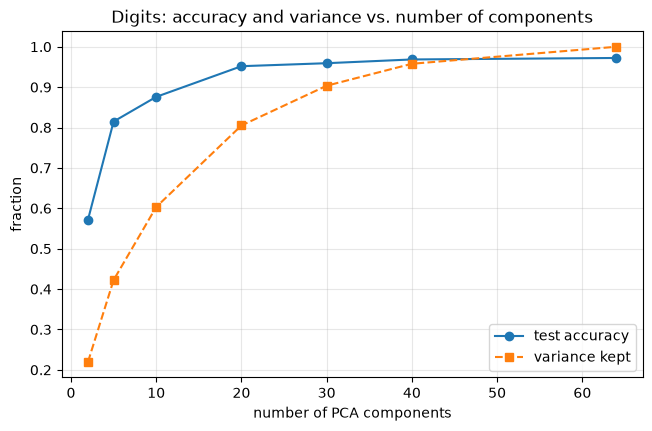

,share of the 64 dims,variance kept,test accuracy
components,,,
2,0.031,0.220,0.572
5,0.078,0.422,0.815
10,0.156,0.603,0.876
20,0.312,0.805,0.952
30,0.469,0.904,0.959
40,0.625,0.958,0.969
64,1.000,1.000,0.972


In [31]:
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(digits.data, digits.target, test_size=0.3,
                                              random_state=0, stratify=digits.target)
rows = []
for k in [2, 5, 10, 20, 30, 40, 64]:
    pipe = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=k)),
                     ("clf", LogisticRegression(max_iter=3000))]).fit(Xd_tr, yd_tr)
    rows.append({"components": k,
                 "share of the 64 dims": k / 64,
                 "variance kept": pipe.named_steps["pca"].explained_variance_ratio_.sum(),
                 "test accuracy": pipe.score(Xd_te, yd_te)})
sweep = pd.DataFrame(rows).set_index("components")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sweep.index, sweep["test accuracy"], "o-", label="test accuracy")
ax.plot(sweep.index, sweep["variance kept"], "s--", label="variance kept")
ax.set_xlabel("number of PCA components"); ax.set_ylabel("fraction"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Digits: accuracy and variance vs. number of components")
plt.show()

sweep.round(3)

Accuracy climbs steeply and then flattens. With 40 of the 64 dimensions (≈ 63 %), accuracy (0.969) is within a hair of the full model (0.972); the 0.3-point difference is under two images out of the 540 test images, so statistically it is a tie. Below ≈ 20 components the loss is clear (2 components: 0.57). Note also that the **variance** curve rises much more slowly than accuracy: 10 components keep only ≈ 60 % of the variance yet reach about 88 % accuracy.

(Training times are omitted on purpose: with only 1 797 samples every fit takes milliseconds, so there is nothing to measure. The speed benefit the book mentions becomes visible on much larger data.)

Instead of reading the table by eye, `GridSearchCV` can choose the number of components by cross-validation, which is the principled way to use `n_components` as a hyperparameter:

In [32]:
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("pca", PCA()), ("clf", LogisticRegression(max_iter=3000))]),
    param_grid={"pca__n_components": [5, 10, 20, 30, 40, 50]},
    cv=5,
).fit(Xd_tr, yd_tr)

print("best n_components:", search.best_params_["pca__n_components"])
print(f"cross-validated accuracy: {search.best_score_:.3f}")
print(f"held-out test accuracy  : {search.score(Xd_te, yd_te):.3f}")

best n_components: 50
cross-validated accuracy: 0.963
held-out test accuracy  : 0.974


The search picked **50**, the largest value in the grid. Together with the sweep above (accuracy almost flat from 40 components upward) this says the exact choice between 40 and 50 matters little, and that for Digits the useful range is roughly "a bit more than half of the 64 dimensions". Because the optimum lies at the *edge* of the grid, a careful analyst would also try larger values (e.g. 55-64) before declaring 50 the best.

### 6.3 Exercise 2 (book): t-SNE for visualisation + k-means

The book's second exercise: take the complex dataset, apply K-means, then draw **side-by-side plots**, one coloured by the true labels, one by the cluster labels. (The book's introduction mentions "impact on subsequent classification", but the listed steps are about clustering, which is what we implement.)

We cluster the original standardised 64-D data, show the result on the t-SNE map, and score the clustering against the true digits with two standard measures: the **Adjusted Rand Index** (ARI) and **Normalised Mutual Information** (NMI). Both are 1 for a perfect match and about 0 for a random one.

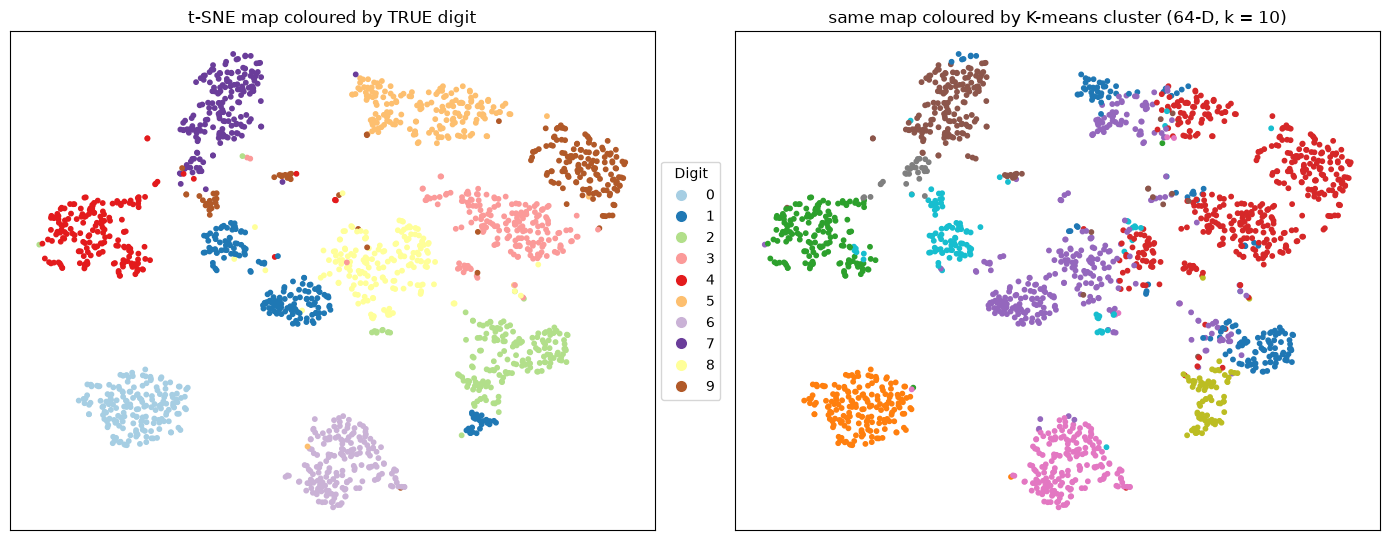

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

km_64d = KMeans(n_clusters=10, n_init=10, random_state=0)
labels_64d = km_64d.fit_predict(Z_digits)                         # clustering in the full 64-D space

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_digits_2d(axes[0], X_tsne, digits.target, "t-SNE map coloured by TRUE digit", legend=True)
sc = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_64d, cmap="tab10", s=10)
axes[1].set_title("same map coloured by K-means cluster (64-D, k = 10)")
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout(); plt.show()

In [34]:
labels_on_map = KMeans(n_clusters=10, n_init=10, random_state=0).fit_predict(X_tsne)   # clustering the 2-D map instead

pd.DataFrame({
    "K-means on standardised 64-D data": {"ARI": adjusted_rand_score(digits.target, labels_64d),
                                           "NMI": normalized_mutual_info_score(digits.target, labels_64d)},
    "K-means on the 2-D t-SNE map":      {"ARI": adjusted_rand_score(digits.target, labels_on_map),
                                           "NMI": normalized_mutual_info_score(digits.target, labels_on_map)},
}).T.round(3)

,ARI,NMI
K-means on standardised 64-D data,0.468,0.626
K-means on the 2-D t-SNE map,0.781,0.839


Two observations:

* **Visual check:** the K-means colouring (right) mostly follows the digit islands (left), but some digits are split across several clusters and some clusters mix digits (typically the visually similar ones). The map helps *diagnose* where a clustering agrees with the labels.
* **Numbers:** K-means in the raw 64-D space reaches ARI ≈ 0.47, while K-means on the 2-D t-SNE map reaches ≈ 0.78. The map has already concentrated each digit into a compact region, which k-means handles easily.

A **warning** on the second number: it is not a fair "model score". The t-SNE map was computed from *all* the data, cannot embed new samples (Section 4.6) and its cluster shapes are not guaranteed to be meaningful, so use it to *explore* and *explain*, not as a recipe for clustering production data.

### 6.4 Putting it together

* **Visualise first** (PCA for the global picture, t-SNE for local structure), to see whether the classes are separable at all.
* **Reduce for modelling** with PCA (unsupervised) or LDA (supervised, ≤ K−1 dimensions), *inside the pipeline*, and choose the number of components by cross-validation.
* **Always compare against the unreduced baseline** on held-out data: sometimes you will save dimensions at no cost (Digits, 40 of 64), sometimes the reduction only hurts (Iris, 4 features).

## Chapter summary

| Technique | Class | Idea | Strengths | Limits |
|-----------|-------|------|-----------|--------|
| **PCA** | `decomposition.PCA` | orthogonal directions of maximum variance | fast, `transform` for new data, denoising, good default | needs scaling; blends are hard to interpret; variance ≠ class information |
| **LDA** | `discriminant_analysis.LinearDiscriminantAnalysis` | directions that maximise between-class vs. within-class scatter | best linear class separation, also a classifier | needs labels; at most K−1 components; Gaussian/shared-covariance assumptions; overfits easily when p ≫ n |
| **t-SNE** | `manifold.TSNE` | map that preserves local neighbourhoods | reveals clusters and non-linear structure | visualisation only (no `transform`), slow, random, perplexity-sensitive, distances between clusters not meaningful |

### Key takeaways

* **More dimensions are not better**: distances lose contrast as dimension grows (relative contrast fell from hundreds to 0.17).
* **Scale first, fit on training data only.** Unscaled PCA is hijacked by the biggest-unit feature (99.8 % "explained" by `proline`), and supervised reducers fitted outside the pipeline report 100 % accuracy on noise.
* **Choose by goal:** classification with labels → LDA; general-purpose preprocessing → PCA; looking at the data → t-SNE (with PCA for the global view).
* **Retaining variance is not retaining signal**: Iris kept 96 % of the variance with 2 components yet lost a few points of accuracy.
* **Always benchmark** the reduced model against the full one using cross-validation or a held-out set.

### Self-check questions

<details><summary><b>Q1.</b> Why does PCA require standardised features?</summary>

PCA maximises variance, and variance depends on units. Without scaling, the feature with the largest numbers dominates the first component (for Wine, PC1 was essentially `proline` and "explained" 99.8 % of the variance).
</details>

<details><summary><b>Q2.</b> What is the maximum number of LDA components for a problem with 10 classes and 64 features, and why?</summary>

min(64, 10 − 1) = 9. The between-class scatter matrix is built from 10 class means, so its rank is at most 9.
</details>

<details><summary><b>Q3.</b> Why is PCA a reasonable pipeline step for a model but t-SNE is not?</summary>

PCA has a <code>transform()</code> that can be applied to unseen data with the learned axes. <code>TSNE</code> only has <code>fit_transform</code>: it cannot embed new samples, is stochastic and slow, so it is meant for visualisation.
</details>

<details><summary><b>Q4.</b> LDA's scatter plot of a dataset looks perfectly separated. Is that evidence that the classes are separable?</summary>

Not by itself. LDA uses the labels, and with many features relative to samples it can separate even random labels (our noise experiment gave three clearly separated clusters and 100 % leaky accuracy, versus about chance level when evaluated honestly). Check with cross-validation, with LDA inside the pipeline.
</details>

<details><summary><b>Q5.</b> What does perplexity control in t-SNE, and what happens if it is too small?</summary>

It is the effective number of neighbours each point considers. Too small a value makes the map fragment into many tiny groups because only very local structure is seen.
</details>

<details><summary><b>Q6.</b> The 2 PCA components on Iris keep 96 % of the variance, yet accuracy fell. How can that be?</summary>

Variance and class information are different things: PCA keeps directions with large spread, but the small discarded part can still contain what separates the classes.
</details>

---
**Reference:** Sukup, J. *scikit-learn Cookbook, Third Edition*, Chapter 3, "Dimensionality Reduction Techniques". Examples were re-run and extended by the author of this notebook; explanations are paraphrased and supplemented with extra experiments.